In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

analytics_df = pd.read_csv("analytics_df.csv")

In [54]:
# KPI 1

total_revenue = analytics_df["price"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $13,591,643.70


In [55]:
# KPI 2

total_orders = analytics_df["order_id"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 99,441


In [56]:
# KPI 3

total_customers = analytics_df["customer_unique_id"].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 96,096


In [57]:
# KPI 4

total_sellers = analytics_df["seller_id"].nunique()

print(f"Total Sellers: {total_sellers:,}")

Total Sellers: 3,095


In [58]:
# KPI aveage order value

aov = (
    analytics_df
    .groupby("order_id")["price"]
    .sum()
    .mean()
)

print(f"AOV: ${aov:,.2f}")

AOV: $136.68


In [59]:
# KPI 6 — Average Delivery Time
avg_delivery = analytics_df["delivery_time_days"].mean()

print(f"Average Delivery Time: {avg_delivery:.2f} Days")

Average Delivery Time: 12.01 Days


In [60]:
# KPI 7 — Average Review Score

avg_rating = analytics_df["review_score"].mean()

print(f"Average Rating: {avg_rating:.2f}")

Average Rating: 4.02


In [61]:
summary = pd.DataFrame({
    "Metric":[
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Sellers",
        "Average Order Value",
        "Average Delivery Time",
        "Average Review Score"
    ],
    "Value":[
        f"${total_revenue:,.2f}",
        total_orders,
        total_customers,
        total_sellers,
        f"${aov:,.2f}",
        f"{avg_delivery:.2f} Days",
        f"{avg_rating:.2f}"
    ]
})

summary

,Metric,Value
0,Total Revenue,"$13,591,643.70"
1,Total Orders,99441
2,Total Customers,96096
3,Total Sellers,3095
4,Average Order Value,$136.68
5,Average Delivery Time,12.01 Days
6,Average Review Score,4.02


In [62]:
analytics_df.shape

(113425, 46)

# SALES ANALYSIS

In [63]:
monthly_sales = (
    analytics_df
    .groupby(["purchase_year", "purchase_month", "purchase_month_name"])["price"]
    .sum()
    .reset_index()
    .sort_values(["purchase_year", "purchase_month"])
)

monthly_sales

,purchase_year,purchase_month,purchase_month_name,price
0,2016,9,September,267.36
1,2016,10,October,49507.66
2,2016,12,December,10.90
3,2017,1,January,120312.87
4,2017,2,February,247303.02
5,2017,3,March,374344.30
6,2017,4,April,359927.23
7,2017,5,May,506071.14
8,2017,6,June,433038.60
9,2017,7,July,498031.48


In [64]:
analytics_df.groupby(["purchase_year","purchase_month"]).size()

purchase_year  purchase_month
2016           9                    7
               10                 379
               12                   1
2017           1                  966
               2                 1998
               3                 3041
               4                 2697
               5                 4176
               6                 3611
               7                 4576
               8                 4948
               9                 4873
               10                5385
               11                8758
               12                6357
2018           1                 8257
               2                 7706
               3                 8240
               4                 7980
               5                 7945
               6                 7085
               7                 7111
               8                 7308
               9                   16
               10                   4
dtype: int64

In [65]:
monthly_sales = monthly_sales[
    ~(
        (monthly_sales["purchase_year"] == 2018) &
        (monthly_sales["purchase_month"] >= 9)
    )
]

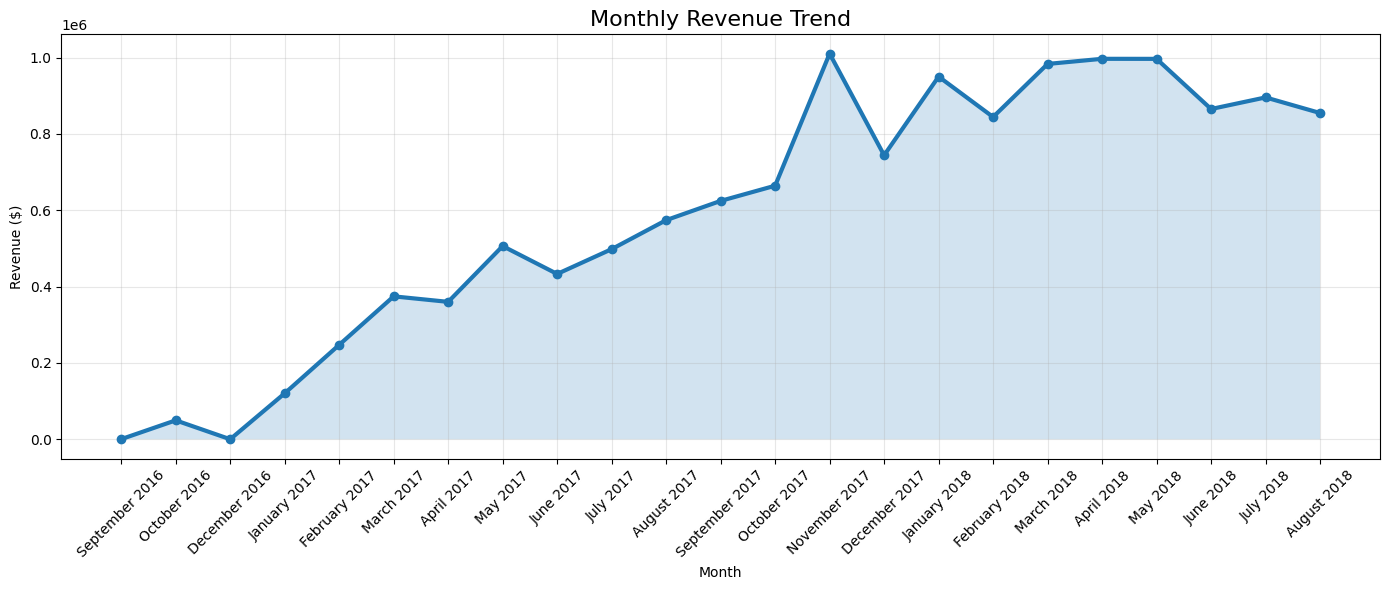

In [66]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["purchase_month_name"] + " " +
    monthly_sales["purchase_year"].astype(str),
    monthly_sales["price"],
    marker="o",
    linewidth=3
)

plt.fill_between(
    monthly_sales["purchase_month_name"] + " " +
    monthly_sales["purchase_year"].astype(str),
    monthly_sales["price"],
    alpha=0.2
)

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Insight from monthly sales

The marketplace experienced strong growth during 2017, followed by a more stable revenue pattern in 2018, indicating business maturity. The November peak suggests the impact of seasonal shopping events such as Black Friday.

# Analysis 2: Revenue by Product Category

In [67]:
category_revenue = (
    analytics_df
    .groupby("product_category")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()

)

category_revenue.columns = ["Product Category", "Revenue"]

category_revenue["Revenue Contribution (%)"] = (
    category_revenue["Revenue"] /
    category_revenue["Revenue"].sum()
) * 100

# Round values
category_revenue["Revenue"] = category_revenue["Revenue"].round(2)
category_revenue["Revenue Contribution (%)"] = (
    category_revenue["Revenue Contribution (%)"].round(2)
)

category_revenue.head(10)

,Product Category,Revenue,Revenue Contribution (%)
0,health_beauty,1258681.34,9.39
1,watches_gifts,1205005.68,8.99
2,bed_bath_table,1036988.68,7.73
3,sports_leisure,988048.97,7.37
4,computers_accessories,911954.32,6.80
5,furniture_decor,729762.49,5.44
6,cool_stuff,635290.85,4.74
7,housewares,632248.66,4.72
8,auto,592720.11,4.42
9,garden_tools,485256.46,3.62


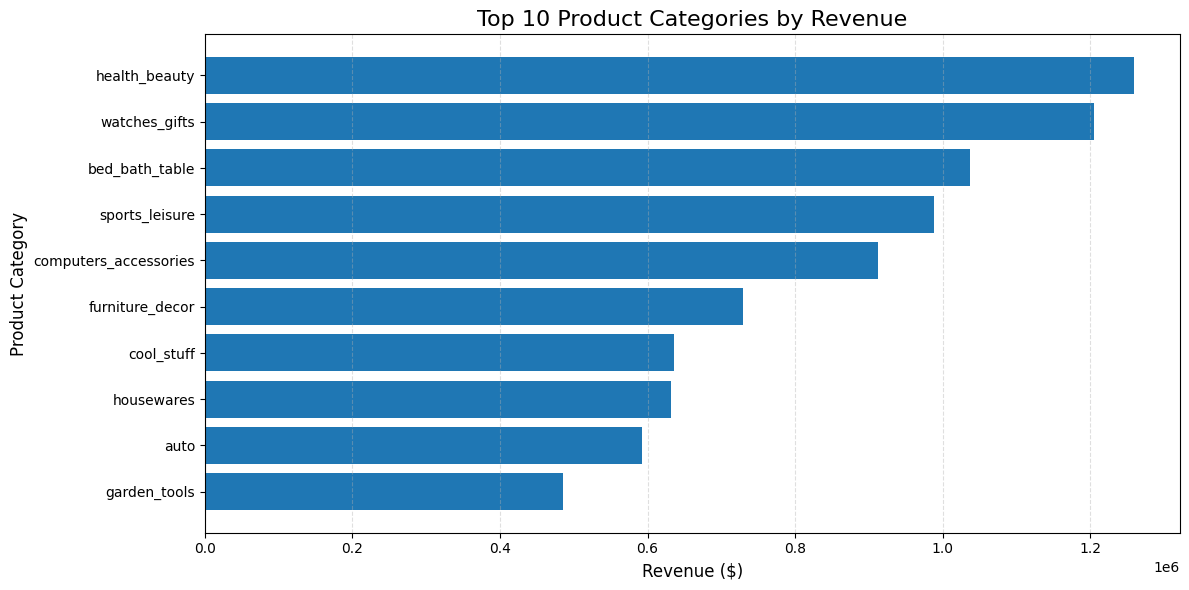

In [68]:
top10 = category_revenue.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["Product Category"],
    top10["Revenue"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Product Categories by Revenue", fontsize=16)
plt.xlabel("Revenue ($)", fontsize=12)
plt.ylabel("Product Category", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

A small number of product categories contribute a significant portion of total revenue. These categories are the core revenue drivers of the marketplace and should remain a strategic focus.

# Analysis 3: Monthly Order Trend

In [69]:
monthly_orders = (
    analytics_df
    .groupby(["purchase_year", "purchase_month", "purchase_month_name"])["order_id"]
    .nunique()
    .reset_index(name="Total Orders")
    .sort_values(["purchase_year", "purchase_month"])
)

monthly_orders.head()

,purchase_year,purchase_month,purchase_month_name,Total Orders
0,2016,9,September,4
1,2016,10,October,324
2,2016,12,December,1
3,2017,1,January,800
4,2017,2,February,1780


In [70]:
monthly_orders = monthly_orders[
    ~(
        (monthly_orders["purchase_year"] == 2018) &
        (monthly_orders["purchase_month"] >= 9)
    )
]

monthly_orders.tail()

,purchase_year,purchase_month,purchase_month_name,Total Orders
18,2018,4,April,6939
19,2018,5,May,6873
20,2018,6,June,6167
21,2018,7,July,6292
22,2018,8,August,6512


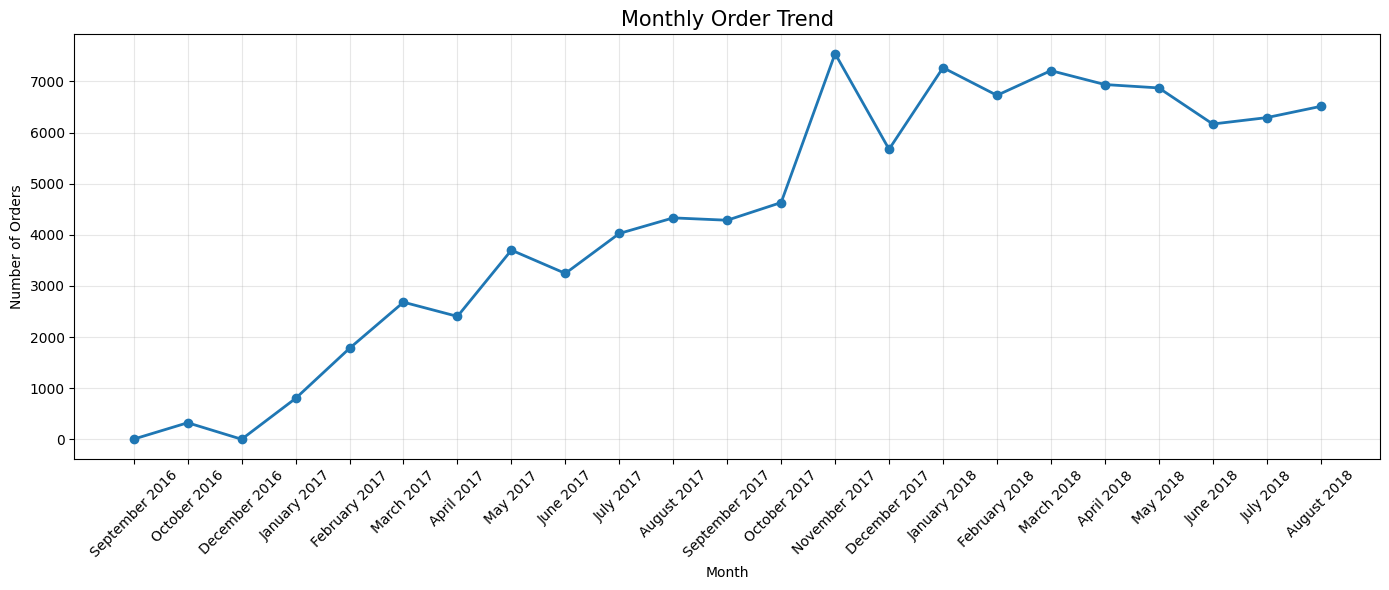

In [71]:
# Create Month-Year label

monthly_orders["Month-Year"] = (
    monthly_orders["purchase_month_name"] + " " +
    monthly_orders["purchase_year"].astype(str)
)

# Plot

plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders["Month-Year"],
    monthly_orders["Total Orders"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Order Trend", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Business Insight

The monthly order trend closely mirrors the monthly revenue trend, indicating that business growth is primarily driven by an increase in customer orders rather than higher spending per order. The significant peak observed in November 2017 suggests the influence of seasonal shopping events, while the stable order volume throughout 2018 indicates that the marketplace maintained consistent customer demand.

# Analysis 4: Revenue by State

In [72]:
state_revenue = (
    analytics_df
    .groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

state_revenue.columns = ["State", "Revenue"]

state_revenue["Revenue Contribution (%)"] = (
    state_revenue["Revenue"] /
    state_revenue["Revenue"].sum()
) * 100

state_revenue["Revenue"] = state_revenue["Revenue"].round(2)
state_revenue["Revenue Contribution (%)"] = (
    state_revenue["Revenue Contribution (%)"].round(2)
)

state_revenue.head(10)

,State,Revenue,Revenue Contribution (%)
0,SP,5202955.05,38.28
1,RJ,1824092.67,13.42
2,MG,1585308.03,11.66
3,RS,750304.02,5.52
4,PR,683083.76,5.03
5,SC,520553.34,3.83
6,BA,511349.99,3.76
7,DF,302603.94,2.23
8,GO,294591.95,2.17
9,ES,275037.31,2.02


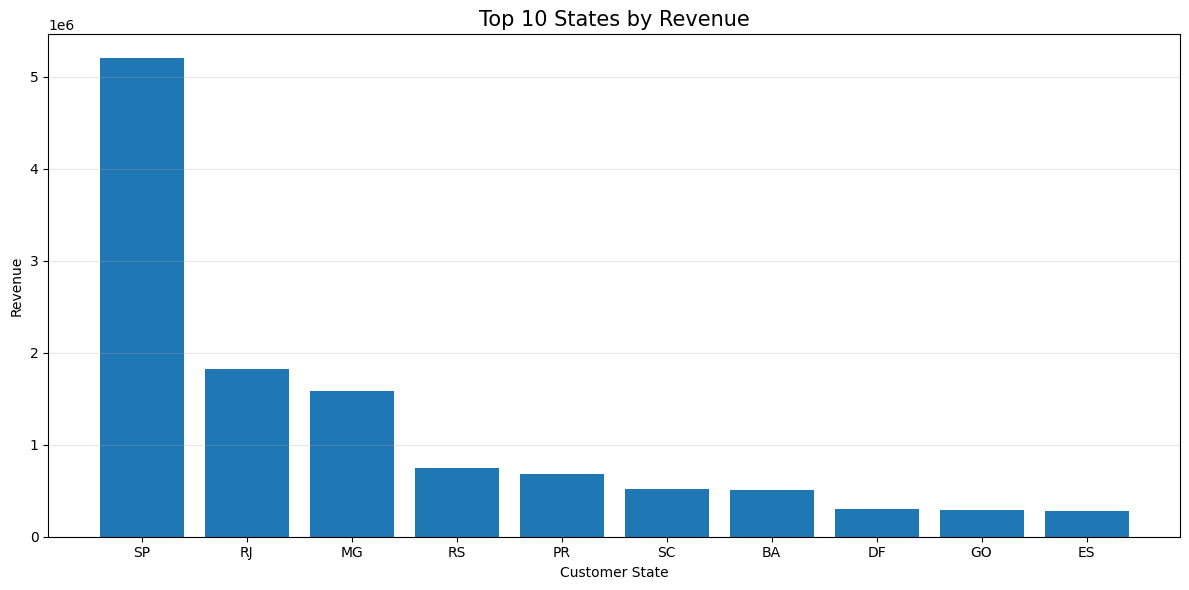

In [73]:
top10_states = state_revenue.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10_states["State"],
    top10_states["Revenue"]
)

plt.title("Top 10 States by Revenue", fontsize=15)
plt.xlabel("Customer State")
plt.ylabel("Revenue")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Customer Distribution by State

In [74]:
customer_state = (
    analytics_df
    .groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

customer_state.columns = ["State", "Total Customers"]

customer_state.head(10)

,State,Total Customers
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


# Business Insight from analysis 4

The high revenue generated from São Paulo is largely driven by its large customer base rather than concluding that customers there necessarily spend more individually.


Business recommendation :

Continue investing in customer acquisition and retention in SP since it is the largest revenue market.


# Analysis 5: Average Order Value (AOV) by State

In [75]:
# Calculate total revenue and total orders for each state

state_aov = (
    analytics_df
    .groupby("customer_state")
    .agg(
        Total_Revenue=("price", "sum"),
        Total_Orders=("order_id", "nunique")
    )
    .reset_index()
)

# Calculate Average Order Value

state_aov["Average_Order_Value"] = (
    state_aov["Total_Revenue"] /
    state_aov["Total_Orders"]
)

# Sort by AOV

state_aov = state_aov.sort_values(
    by="Average_Order_Value",
    ascending=False
)

state_aov.head(10)

,customer_state,Total_Revenue,Total_Orders,Average_Order_Value
14,PB,115268.08,536,215.052388
3,AP,13474.30,68,198.151471
0,AC,15982.95,81,197.320370
1,AL,80314.81,413,194.466852
13,PA,178947.81,975,183.536215
20,RO,46140.64,253,182.374071
26,TO,49621.74,280,177.220500
16,PI,86914.08,495,175.584000
12,MT,156453.53,907,172.495623
19,RN,83034.98,485,171.206144


In [76]:
state_aov = (
    state_aov[state_aov["Total_Orders"] >= 500]
    .sort_values(by="Average_Order_Value", ascending=False)
    .reset_index(drop=True)
)

state_aov.head(10)

,customer_state,Total_Revenue,Total_Orders,Average_Order_Value
0,PB,115268.08,536,215.052388
1,PA,178947.81,975,183.536215
2,MT,156453.53,907,172.495623
3,CE,227254.71,1336,170.100831
4,MS,116812.64,715,163.374322
5,MA,119648.22,747,160.171647
6,PE,262788.03,1652,159.072657
7,BA,511349.99,3380,151.286979
8,GO,294591.95,2020,145.837599
9,SC,520553.34,3637,143.127121


# Business insight

States generating the highest revenue are not necessarily the states where customers spend the most per order. While São Paulo drives overall revenue through a large customer base, states such as Paraíba (PB) generate higher revenue per order, indicating customers in those regions tend to place higher-value purchases.

# Product Analysis 1: Revenue by Product Category

In [77]:
category_revenue = (
    analytics_df
    .groupby("product_category")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue.columns = ["Product Category", "Revenue"]

# Revenue Contribution %

category_revenue["Revenue Contribution (%)"] = (
    category_revenue["Revenue"] /
    category_revenue["Revenue"].sum()
) * 100

category_revenue = category_revenue.round(2)

category_revenue.head(10)

,Product Category,Revenue,Revenue Contribution (%)
0,health_beauty,1258681.34,9.39
1,watches_gifts,1205005.68,8.99
2,bed_bath_table,1036988.68,7.73
3,sports_leisure,988048.97,7.37
4,computers_accessories,911954.32,6.80
5,furniture_decor,729762.49,5.44
6,cool_stuff,635290.85,4.74
7,housewares,632248.66,4.72
8,auto,592720.11,4.42
9,garden_tools,485256.46,3.62


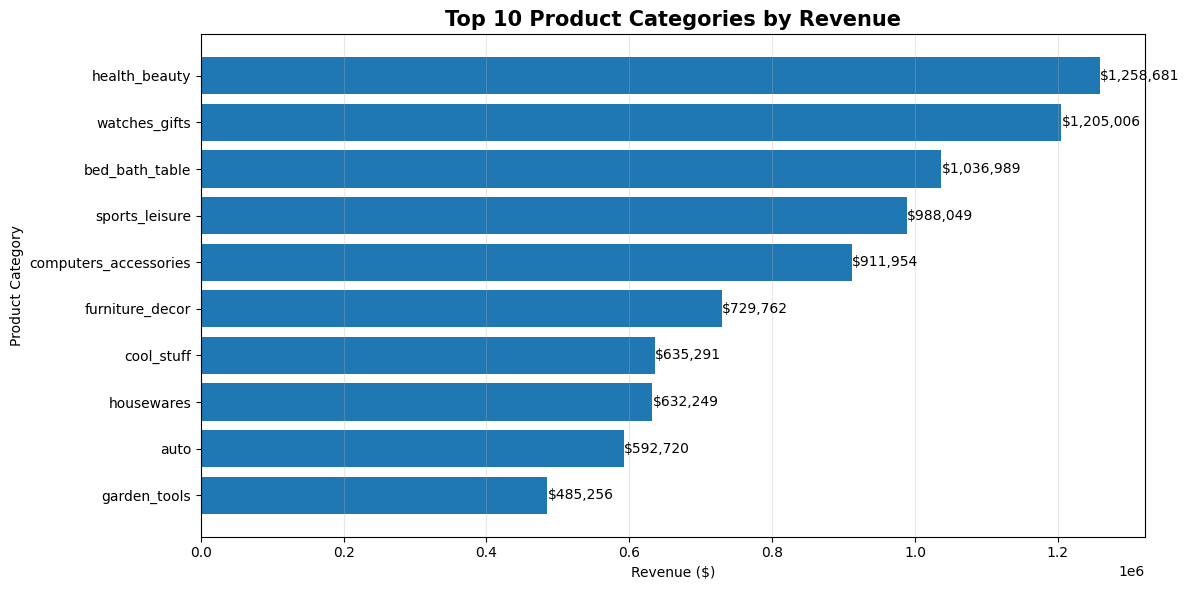

In [78]:
# Top 10 Categories
top10_categories = category_revenue.head(10)

plt.figure(figsize=(12,6))

bars = plt.barh(
    top10_categories["Product Category"],
    top10_categories["Revenue"]
)

# Highest revenue on top
plt.gca().invert_yaxis()

# Add revenue labels
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"${bar.get_width():,.0f}",
        va='center',
        fontsize=10
    )

plt.title("Top 10 Product Categories by Revenue", fontsize=15, weight='bold')
plt.xlabel("Revenue ($)")
plt.ylabel("Product Category")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

# Business insight

Revenue is well distributed across multiple product categories. No single category dominates the marketplace, suggesting that Olist has a diversified revenue portfolio rather than relying heavily on one product segment.

# Calculate Sales Volume

In [79]:
category_volume = (
    analytics_df
    .groupby("product_category")["order_item_id"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
)

category_volume.columns = ["Product Category", "Items Sold"]

category_volume.head(10)

,Product Category,Items Sold
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827
5,housewares,6964
6,watches_gifts,5991
7,telephony,4545
8,garden_tools,4347
9,auto,4235


# Bussiness insight

Different product categories follow different revenue strategies:
*  Volume-driven categories (e.g., Bed Bath & Table) generate revenue by selling many items.
*   Premium-driven categories (e.g., Watches & Gifts) generate revenue through higher-priced products.

Understanding this distinction helps the business decide whether to focus on increasing sales volume or promoting premium products.


# Seller Analysis 1 : Top-performing sellers by revenue

In [80]:
seller_revenue = (
    analytics_df
    .groupby("seller_id")
    .agg(
        Total_Revenue=("price", "sum"),
        Total_Orders=("order_id", "nunique")
    )
    .reset_index()
)

seller_revenue = seller_revenue.sort_values(
    by="Total_Revenue",
    ascending=False
).reset_index(drop=True)

seller_revenue.head(10)

,seller_id,Total_Revenue,Total_Orders
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132
1,53243585a1d6dc2643021fd1853d8905,222776.05,358
2,4a3ca9315b744ce9f8e9374361493884,200472.92,1806
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,982
5,7e93a43ef30c4f03f38b393420bc753a,176431.87,336
6,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314
7,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160
8,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915
9,955fee9216a65b617aa5c0531780ce60,135171.70,1287


Top sellers follow different business models. Some sellers generate high revenue through many orders, while others achieve similar revenue with fewer orders, suggesting they sell higher-value products.

# Seller Analysis 2 : Calculate Revenue by Seller State

In [81]:
seller_state_revenue = (
    analytics_df
    .groupby("seller_state")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

seller_state_revenue.columns = ["Seller State", "Revenue"]

seller_state_revenue.head(10)

,Seller State,Revenue
0,SP,8753396.21
1,PR,1261887.21
2,MG,1011564.74
3,RJ,843984.22
4,SC,632426.07
5,RS,378559.54
6,BA,285561.56
7,DF,97749.48
8,PE,91493.85
9,GO,66399.21


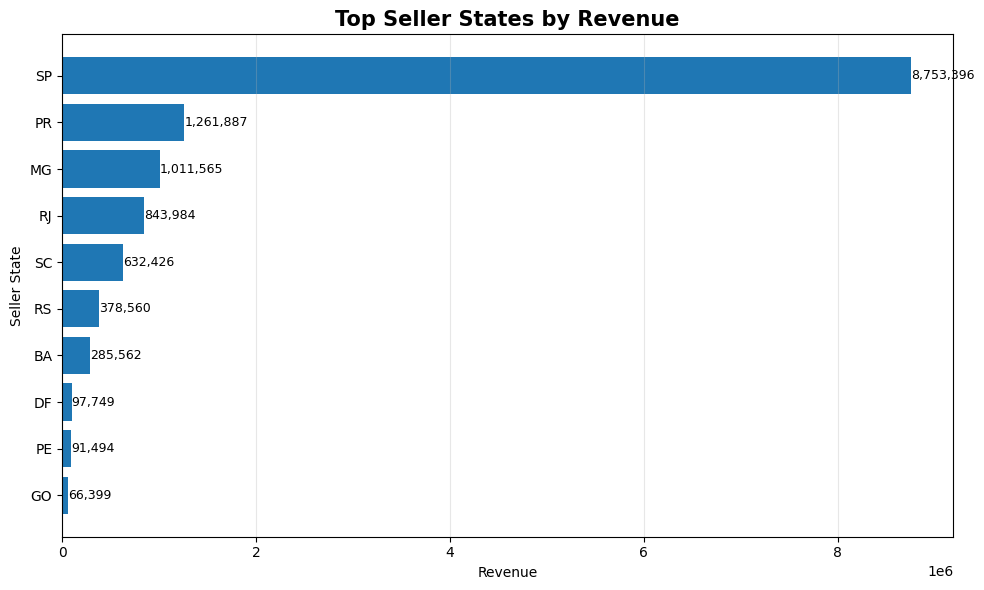

In [82]:
top10_states = seller_state_revenue.head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top10_states["Seller State"],
    top10_states["Revenue"]
)

plt.gca().invert_yaxis()

# Revenue labels
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        fontsize=9
    )

plt.title("Top Seller States by Revenue", fontsize=15, weight="bold")
plt.xlabel("Revenue")
plt.ylabel("Seller State")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

The seller ecosystem appears to be highly concentrated in São Paulo. This may be because SP has a larger number of active sellers, a higher product assortment, or higher sales volume compared to other states.

Olist should continue strengthening its seller network in São Paulo while also encouraging seller growth in other states. A more geographically distributed seller base could improve delivery efficiency and reduce logistics costs for customers across Brazil

# Logistics Analysis 1 : Delivery Time Distribution

In [83]:
# Summary statistics for delivery time

analytics_df["delivery_time_days"].describe()

,delivery_time_days
count,110196.000000
mean,12.007723
std,9.451455
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


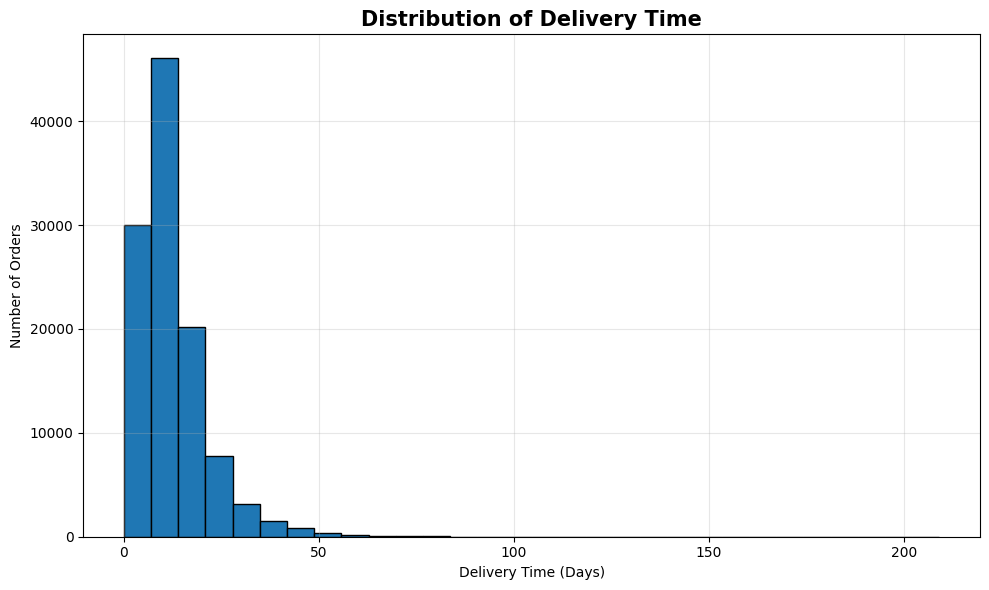

In [84]:
plt.figure(figsize=(10,6))

plt.hist(
    analytics_df["delivery_time_days"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Delivery Time", fontsize=15, weight="bold")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [85]:
analytics_df[
    analytics_df["delivery_time_days"] == analytics_df["delivery_time_days"].max()
][[
    "order_id",
    "customer_state",
    "seller_state",
    "order_status",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "delivery_time_days"
]]

,order_id,customer_state,seller_state,order_status,order_purchase_timestamp,order_delivered_customer_date,delivery_time_days
22305,ca07593549f1816d26a572e06dc1eab6,ES,MG,delivered,2017-02-21 23:31:27,2017-09-19 14:36:39,209.0


Olist's delivery process is generally efficient for the majority of orders. However, a small number of extremely delayed deliveries indicate operational exceptions that may negatively impact customer satisfaction and increase support costs

# Customer Satisfaction Analysis

In [88]:
# Categorize Delivery Delay

analytics_df["delay_category"] = pd.cut(
    analytics_df["delivery_delay_days"],
    bins=[-1000, 0, 3, 7, 1000],
    labels=[
        "On Time / Early",
        "1–3 Days Late",
        "4–7 Days Late",
        "More than 7 Days Late"
    ]
)

# average review by delay category
delay_reviews = (
    analytics_df
    .groupby("delay_category")["review_score"]
    .mean()
    .reset_index()
)

delay_reviews.columns = [
    "Delay Category",
    "Average Review Score"
]

delay_reviews

/tmp/ipykernel_2653/1218570229.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("delay_category")["review_score"]


,Delay Category,Average Review Score
0,On Time / Early,4.208268
1,1–3 Days Late,3.230843
2,4–7 Days Late,2.089810
3,More than 7 Days Late,1.698330


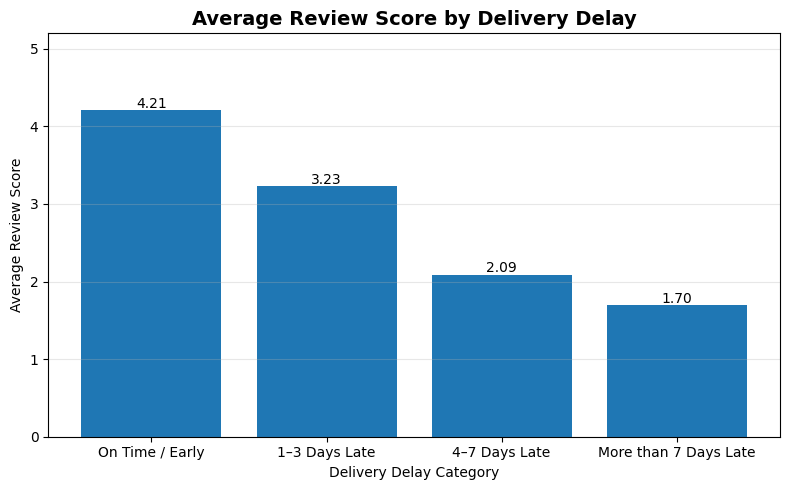

In [89]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    delay_reviews["Delay Category"],
    delay_reviews["Average Review Score"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.03,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=10
    )

plt.title("Average Review Score by Delivery Delay", fontsize=14, weight="bold")
plt.xlabel("Delivery Delay Category")
plt.ylabel("Average Review Score")

plt.ylim(0,5.2)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# Business Insight

Customer satisfaction is strongly associated with delivery performance. As delivery delays increase, customer review scores decline significantly. This indicates that timely delivery is one of the key drivers of a positive customer experience on the Olist marketplace.

# Customer Satisfaction Analysis 2 : Customer ratings distributed

In [90]:
review_distribution = (
    analytics_df["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_distribution.columns = [
    "Review Score",
    "Number of Reviews"
]

review_distribution

,Review Score,Number of Reviews
0,1.000000,14617
1,1.500000,18
2,2.000000,3895
3,2.500000,46
4,3.000000,9437
5,3.333333,1
6,3.500000,31
7,4.000000,21198
8,4.333333,1
9,4.500000,68


In [98]:

review_df = analytics_df.dropna(subset=["review_score"]).copy()

review_distribution = (
    review_df["review_score"]
    .astype(int)
    .value_counts()
    .sort_index()
)

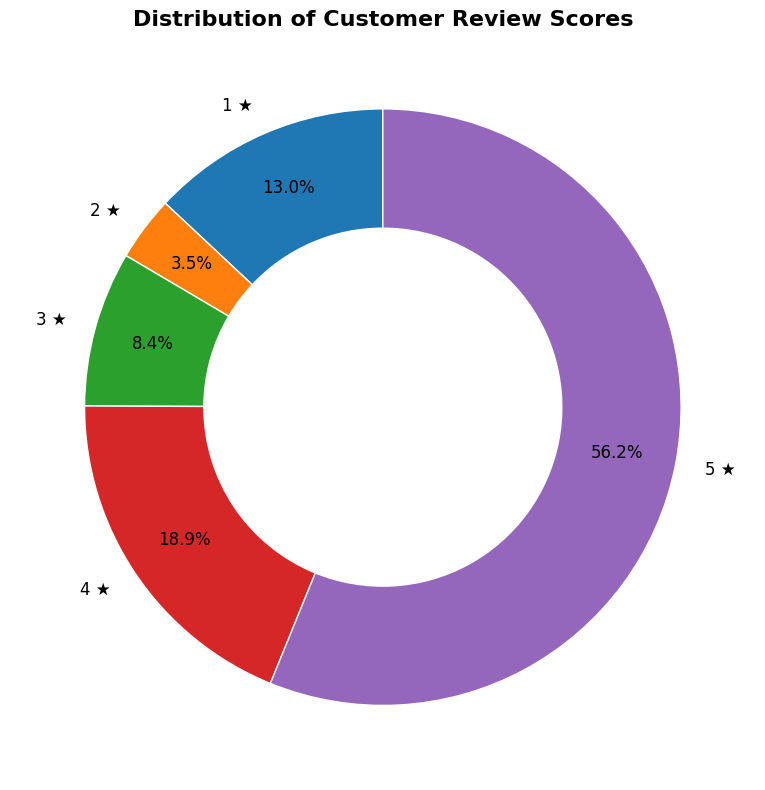

In [99]:
plt.figure(figsize=(8,8))

plt.pie(
    review_distribution.values,
    labels=[f"{score} ★" for score in review_distribution.index],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8,
    wedgeprops=dict(width=0.4, edgecolor="white"),
    textprops={"fontsize":12}
)

plt.title(
    "Distribution of Customer Review Scores",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()
plt.show()

# Business Insight :

 The marketplace maintains a high level of customer satisfaction, with the majority of customers providing positive feedback. This indicates that most customers have a satisfactory purchasing experience.

# Recommendation :

Olist should continue maintaining service quality while investigating the factors behind low-rated reviews to further improve customer satisfaction.

#Executive Summary of Key Insights


# 1.  Business Performance


*   Olist generated approximately $13.59 million in total revenue across 99,441 orders.
*   The marketplace served 96,096 unique customers through 3,095 sellers.


*   The Average Order Value (AOV) was approximately $136.68, indicating a stable average customer spend.


# 2.   Sales Trend


*   Monthly revenue and order volume showed consistent growth throughout 2017.

*   Revenue and orders peaked during late 2017 and remained relatively stable during 2018.
*   This indicates stable and healthy  marketplace growth and increasing customer adoption.



# 3.  Geographic Performance


*   São Paulo (SP) contributed the highest revenue and had the largest customer base.However, higher Average Order Value (AOV) was observed in some smaller states, suggesting opportunities for premium product sales outside major markets.


# 4.   Product Performance


*   Health & Beauty generated the highest revenue among all product categories.
*  Revenue and sales volume differed across categories, suggesting that some categories succeed through higher sales volume while others benefit from higher-priced products.



# 5. Seller Performance


*   Seller revenue was highly concentrated in São Paulo (SP).
*   Top-performing sellers followed different business models, with some generating revenue through high sales volume while others achieved similar revenue with fewer, potentially higher-value, orders.

# 6. Logistics Performance

*  The average delivery time was approximately 12 days and
Most deliveries were completed within 15 days.
*  A small number of extreme delivery delays (up to 209 days) were observed, representing operational exceptions rather than the typical customer experience.

# 7. Customer Satisfaction

*  Most of the customers gave 5-star ratings, indicating generally high customer satisfaction.
*  Customer ratings declined consistently as delivery delays increased.
Orders delivered on time received an average rating above 4, whereas orders delayed by more than 7 days received an average rating below 2.
* This suggests a strong association between delivery performance and customer satisfaction.










# Final Business Recommendations



*   Improve logistics efficiency to reduce delivery delays and enhance customer satisfaction.

*   Continue investing in high-performing product categories while identifying growth opportunities for lower-performing segments.
*   trengthen the seller ecosystem beyond São Paulo to improve geographic coverage and potentially reduce delivery times.


*   Monitor exceptional delivery delays separately to identify operational bottlenecks.
*   Use customer review analysis to continuously improve marketplace quality and customer experience.

